ommunity Detection in Karate Club Network using Recursive Spectral Bisection

DSC 212 Assignment ROHIT VISHNU PADMANE IMS24162

This project implements Newman’s Recursive Spectral Bipartitioning method for community detection in networks. The goal is to identify meaningful groups of nodes by repeatedly splitting the graph based on the leading eigenvector of the modularity matrix, a powerful approach introduced in Newman’s modularity maximization framework.

References : The modularity objective, modularity matrix B, and spectral bipartition method are based on standard results; see Newman (2006), “Modularity and community structure in networks,” PNAS 103(23):8577–8582.


In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm

Helper functions to be called for calculating modularity, node metrics and assigning unique colors.

In [14]:
def modularity_score(B_sub, s, m):  #Function to compute modularity
    return float(s.T @ (B_sub @ s)) / (4.0 * m)

def calculate_metrics(G):  #Function to calculate node metrics whenever required
    return {'degree': nx.degree_centrality(G),
        'betweenness': nx.betweenness_centrality(G),
        'closeness': nx.closeness_centrality(G),
        'clustering': nx.clustering(G)}

def _generate_colors_for_nodes(nodes_list, cmap_name='tab20'):  #Function to assign unique color to each node
    n = len(nodes_list)
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / max(1, n - 1)) for i in range(n)]
    return {node: colors[i] for i, node in enumerate(nodes_list)}

In [15]:
def recursive_bipartition_with_history(A, nodes, m, *,
                                      B_full=None, tol=1e-12,
                                      split_history=None,
                                      communities_snapshot=None,
                                      iteration_counter=None,
                                      G=None,
                                      metrics_history=None):
    if split_history is None:
        split_history = []
    if communities_snapshot is None:
        communities_snapshot = [list(nodes)]
    if iteration_counter is None:
        iteration_counter = [0]
    if metrics_history is None:
        metrics_history = []

    #Compute full modularity matrix B once
    if B_full is None:
        k = A.sum(axis=1)
        B_full = A - np.outer(k, k) / (2.0 * m)

    #Initial metrics snapshot (iteration 0)
    if G is not None and len(metrics_history) == 0:
        m0 = calculate_metrics(G)
        m0['iteration'] = 0
        metrics_history.append(m0)

    def _rec(nodes_local, depth=0):
        idx = np.array(nodes_local, dtype=int)
        B_sub = B_full[np.ix_(idx, idx)]  #Calculating reduced modularity matrix from global modularity matrix

        eigvals, eigvecs = np.linalg.eigh(B_sub)  #Eigenvalue decomposition
        idx_max = np.argmax(eigvals)
        lambda_max = float(eigvals[idx_max])
        v = eigvecs[:, idx_max]

        #Stopping criteria; Can be set based on required sensitivity
        if lambda_max <= tol:
            return [list(nodes_local)]
        if np.all(v >= -tol) or np.all(v <= tol):
            return [list(nodes_local)]

        s = np.where(v > 0, 1.0, -1.0)

        #Modularity gain
        delta_q = modularity_score(B_sub, s, m)

        if delta_q <= tol:
            return [list(nodes_local)]

        group1 = [nodes_local[i] for i in range(len(nodes_local)) if s[i] == 1.0]
        group2 = [nodes_local[i] for i in range(len(nodes_local)) if s[i] == -1.0]

        if len(group1) == 0 or len(group2) == 0:  #If the partition produces an empty group, the split is invalid.
            return [list(nodes_local)]

        #Accepted split is recorded
        iteration_counter[0] += 1
        it = iteration_counter[0]

        #Record metrics snapshot for this iteration
        if G is not None:
            mrec = calculate_metrics(G)
            mrec['iteration'] = it
            metrics_history.append(mrec)

        #Update communities_snapshot
        replaced = False
        for i, comm in enumerate(communities_snapshot):
            if set(comm) == set(nodes_local):
                communities_snapshot[i] = list(group1)
                communities_snapshot.insert(i + 1, list(group2))
                replaced = True
                break
        if not replaced:
            nodes_set = set(nodes_local)
            communities_snapshot[:] = [c for c in communities_snapshot if nodes_set.isdisjoint(set(c))]
            communities_snapshot.append(list(group1))
            communities_snapshot.append(list(group2))

        split_history.append({   #Define new community with dictionary
            'iteration': it,
            'group1': list(group1),
            'group2': list(group2),
            'leading_eigenvalue': lambda_max,
            'delta_q': delta_q,
            'communities_snapshot': [list(c) for c in communities_snapshot]
        })

        #Recurse
        comms = []
        comms.extend(_rec(group1, depth + 1))
        comms.extend(_rec(group2, depth + 1))
        return comms

    final_comms = _rec(nodes, depth=0)
    return final_comms, split_history, metrics_history

In [16]:
def visualize_split_history(G, split_history, final_communities, pos=None, save_each=False, out_prefix='split'):
    nodes_list = list(G.nodes())
    n = len(nodes_list)
    index_to_label = {i: nodes_list[i] for i in range(n)}

    if pos is None: #Generate node positions only once unless provided
        pos = nx.spring_layout(G, seed=42)

    def snapshot_node_colors(snapshot):  #Assign a unique color to each community at a given iteration
        k = len(snapshot)

        cmap = plt.get_cmap('tab20')
        colors = [cmap(i / max(1, k-1)) for i in range(k)]
        label_to_color_idx = {}  #Map each node label to the color index of its community
        for ci, comm in enumerate(snapshot):
            for nd in comm:
                label = index_to_label[nd] if isinstance(nd, int) and nd in range(n) else nd
                label_to_color_idx[label] = ci
        node_colors = []
        for lbl in nodes_list:
            ci = label_to_color_idx.get(lbl, -1)
            if ci >= 0:
                node_colors.append(colors[ci])
            else:  #Safety fallback
                node_colors.append((0.8, 0.8, 0.8, 1.0))
        return node_colors

    for rec in split_history:
        it = rec['iteration']
        snapshot = rec['communities_snapshot']
        node_colors = snapshot_node_colors(snapshot)  #Get colors for this iteration's community structure

        plt.figure(figsize=(10, 7))
        nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=450, font_size=9)  #Draw the graph with appropriate colors

        title = f"Iteration {it} — λ={rec['leading_eigenvalue']:.4f}, ΔQ={rec['delta_q']:.4f}"
        plt.title(title, fontsize=12, fontweight='bold')

        g1 = rec['group1']; g2 = rec['group2']
        def to_labels(lst):
            return [index_to_label[i] if isinstance(i, int) and i in range(n) else i for i in lst]
        txt = f"Group 1 ({len(g1)}): {to_labels(g1)}\n\nGroup 2 ({len(g2)}): {to_labels(g2)}"
        plt.gcf().text(0.02, 0.02, txt, fontsize=9, bbox=dict(facecolor='white', alpha=0.85, boxstyle='round'))
        plt.show()

    #Final communities plot
    final_snapshot = [list(c) for c in final_communities]
    final_colors = snapshot_node_colors(final_snapshot)
    plt.figure(figsize=(10, 8))
    nx.draw(G, pos, node_color=final_colors, with_labels=True, node_size=450, font_size=9)
    plt.title(f"Final communities (k={len(final_communities)})", fontsize=13, fontweight='bold')

    txt_lines = []  #Building descriptive text for all communities
    for i, comm in enumerate(final_communities, 1):
        labels = [index_to_label[j] if isinstance(j, int) and j in range(n) else j for j in comm]
        txt_lines.append(f"C{i} ({len(comm)}): {labels}")
    plt.gcf().text(0.02, 0.02, "\n".join(txt_lines), fontsize=9, bbox=dict(facecolor='white', alpha=0.9, boxstyle='round'))

In [17]:
def node_metric_plot(metrics_history, G, top_k=2, cmap_name='tab20'):
    metric_names = ['degree', 'betweenness', 'closeness', 'clustering']
    metric_labels = {'degree': 'Degree Centrality',
        'betweenness': 'Betweenness Centrality',
        'closeness': 'Closeness Centrality',
        'clustering': 'Clustering Coefficient'}

    if not metrics_history:
        raise ValueError("metrics_history is empty")

    #Ensure iteration numbers
    for i, entry in enumerate(metrics_history):
        entry.setdefault('iteration', i)

    final = metrics_history[-1]
    available = [m for m in metric_names if m in final]
    if not available:  #Determine which metrics are actually available
        raise ValueError("No supported metrics found in metrics_history")

    #Stable node order and colors
    nodes_list = list(G.nodes())
    node_to_color = _generate_colors_for_nodes(nodes_list, cmap_name=cmap_name)

    #Pick top_k using primary metric (first available)
    primary = available[0]
    primary_map = final[primary]
    sorted_nodes = sorted(primary_map.items(), key=lambda x: x[1], reverse=True)
    ranked_nodes = [n for n, _ in sorted_nodes]
    top_nodes = ranked_nodes[:top_k]

    #Subplots
    n_plots = len(available)
    rows, cols = 2, 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
    axes = axes.flatten()

    #Plot evolution of EACH metric
    for ax_idx, metric_name in enumerate(available):
        ax = axes[ax_idx]
        label = metric_labels.get(metric_name, metric_name)

        #Plot all nodes
        for node in nodes_list:
            its, vals = [], []
            for entry in metrics_history:
                mmap = entry.get(metric_name, {})
                if isinstance(mmap, dict) and (node in mmap):
                    its.append(entry['iteration'])
                    vals.append(mmap[node])
            if not its:
                continue
            lw = 3.4 if node in top_nodes else 1.6
            marker = 'o' if node in top_nodes else None
            ax.plot(its, vals, color=node_to_color[node], linewidth=lw, marker=marker, markersize=6 if marker else None, alpha=0.95 if node in top_nodes else 0.9, zorder=3 if node in top_nodes else 1)

        #Aesthetics of the plots
        ax.set_title(label, fontsize=14, fontweight='bold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)



    #Build a legend
    legend_handles = []
    legend_labels = []
    for node in nodes_list:
        is_top = node in top_nodes
        lw = 3.4 if is_top else 1.6
        marker = 'o' if is_top else 's'
        handle = Line2D([0], [0], color=node_to_color[node], lw=lw, marker=marker, markersize=6)
        legend_handles.append(handle)
        legend_labels.append(f'Node {node}')

    ncol = 2
    fig.legend(legend_handles, legend_labels, loc='center right', bbox_to_anchor=(1.02, 0.5),
               ncol=ncol, fontsize=9, frameon=True, title="Nodes")

    plt.tight_layout(rect=(0, 0, 0.82, 1.0))
    plt.show()

Final communities: [[0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21], [4, 5, 6, 10, 16], [14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33], [9], [8, 30]]
Split iterations: [1, 2, 3, 4]
Metric iterations: [0, 1, 2, 3, 4]


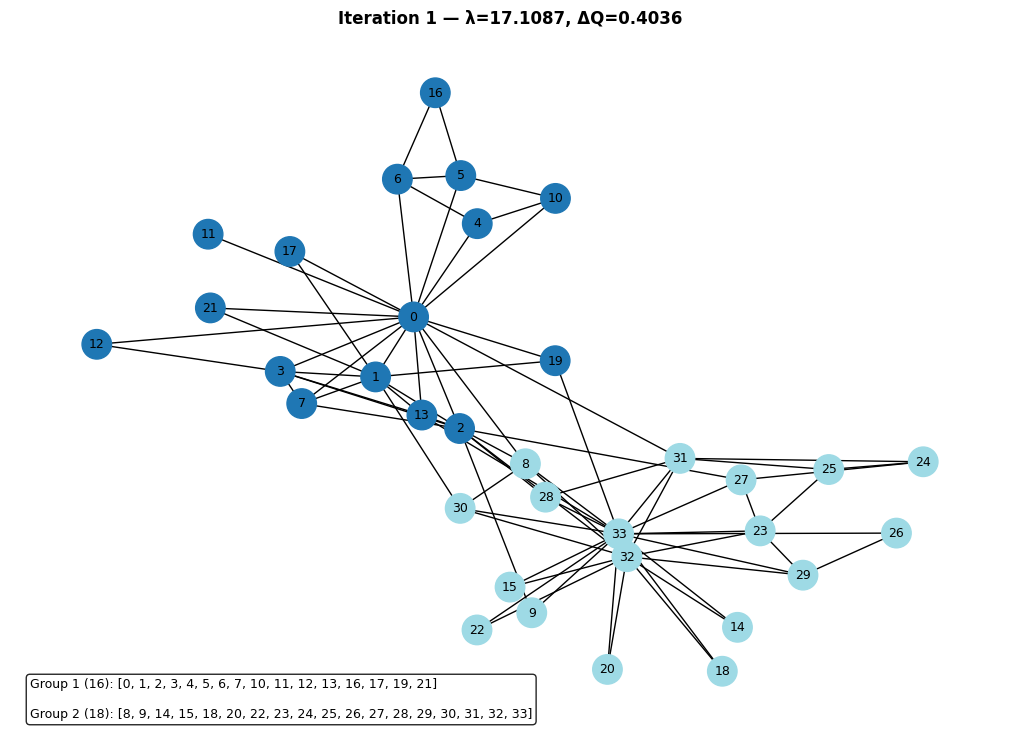

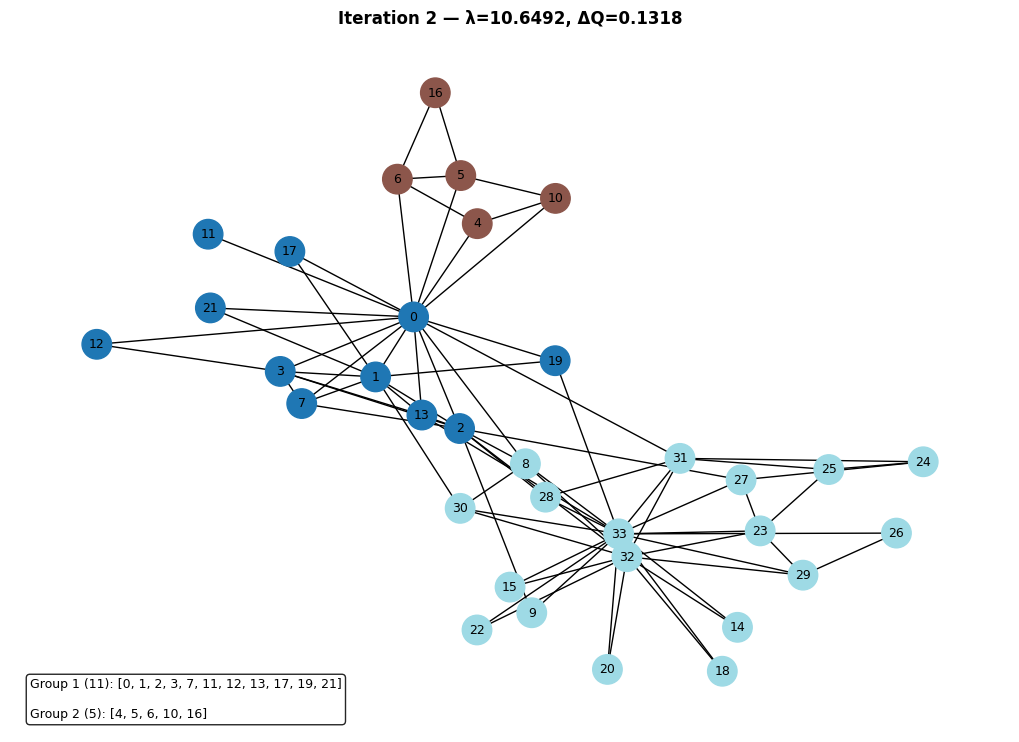

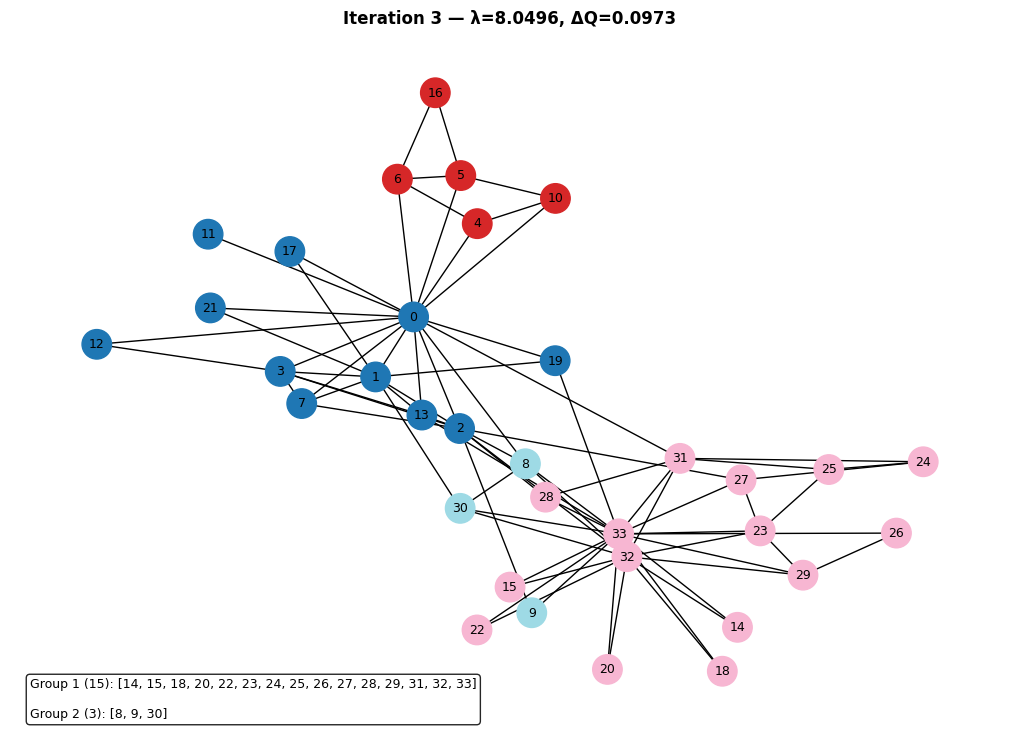

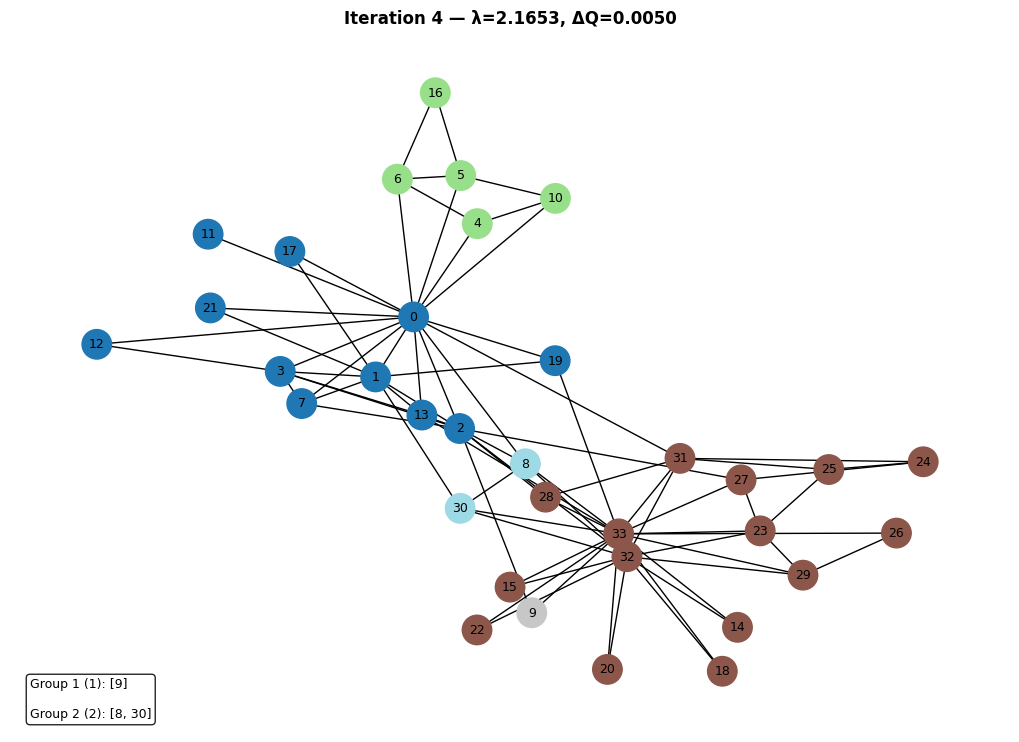

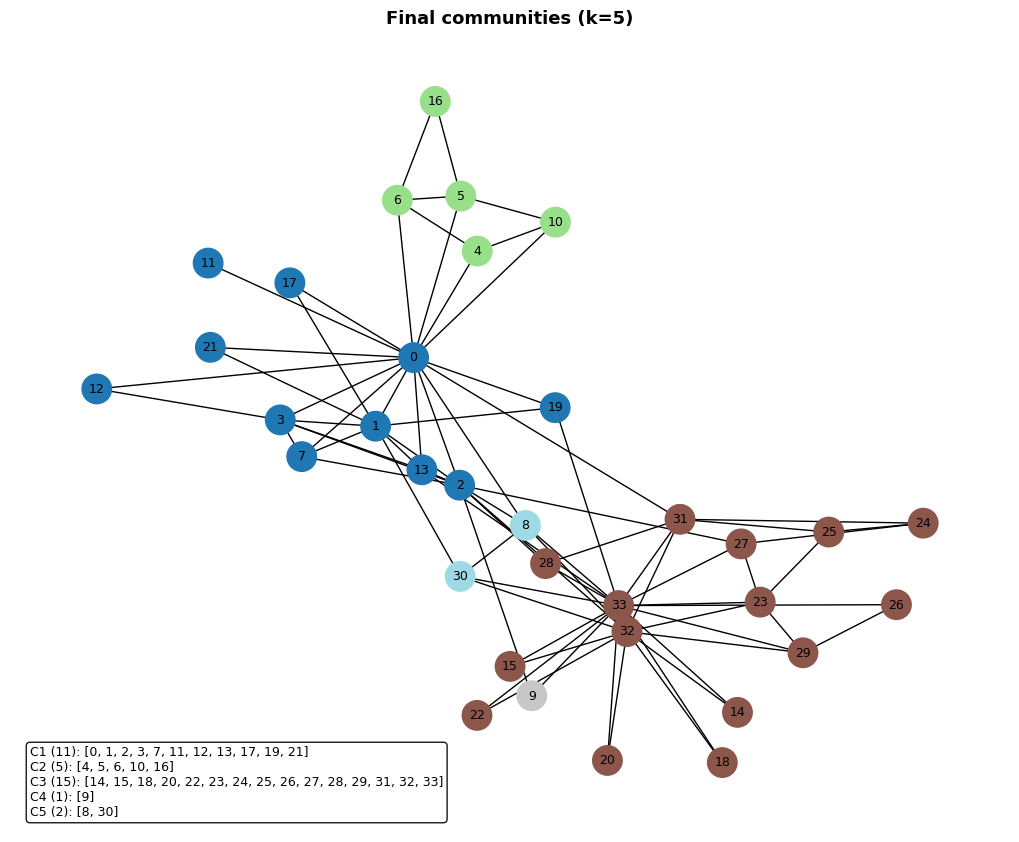

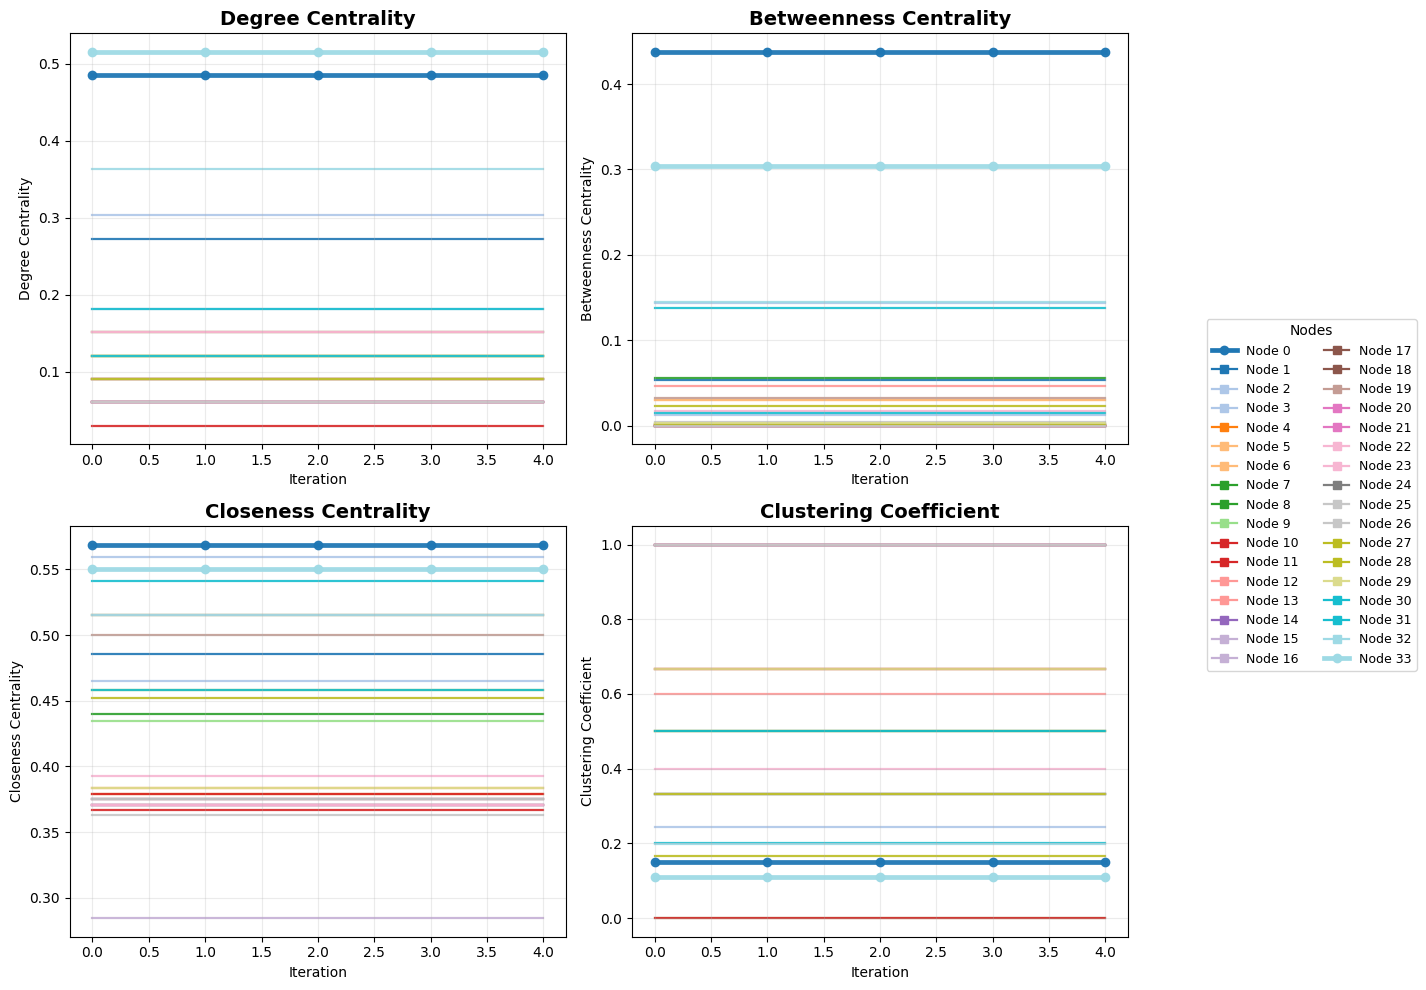

In [18]:
if __name__ == "__main__":
    G = nx.karate_club_graph()
    nodes_list = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes_list)
    m = A.sum() / 2.0


    #Initialize all histories
    split_history = []
    iteration_counter = [0]
    metrics_history = []

    #Performs recursive spectral modularity partitioning
    final_comms, split_history, metrics_history = recursive_bipartition_with_history(
        A, list(range(A.shape[0])), m,
        G=G, split_history=split_history, iteration_counter=iteration_counter, metrics_history=metrics_history
    )

    print("Final communities:", final_comms)
    print("Split iterations:", [r['iteration'] for r in split_history])
    print("Metric iterations:", [r['iteration'] for r in metrics_history])

    pos = nx.spring_layout(G, seed=42)
    visualize_split_history(G, split_history, final_comms, pos=pos)  #Plots the community splits
    node_metric_plot(metrics_history, G, top_k=2)  #Plots the node metrics' variation




Discussion

Looking at all four centrality measures—degree, betweenness, closeness, and clustering—it becomes clear that Nodes 0 and 33 are the most influential points in the network. These nodes correspond to the two leaders of the Karate Club, which explains why they have many direct links and appear on a large number of shortest paths. Since the centrality scores do not change across the splitting steps, the main community structure is already present in the original graph.

As the graph is repeatedly divided, Nodes 0 and 33 often appear near the dividing boundary. Their connections reach across different parts of the network, allowing them to remain central even when communities split.

When spectral bisection is applied, the algorithm naturally forms groups around these highly connected hubs. Node 33, for instance, frequently becomes the core of one side of the partition, drawing in nodes that are closely linked to it.

The overall division of the graph tends to center around Node 0 (the instructor) and Node 33 (the administrator). While smaller communities form from local connection patterns, these two nodes continue to act as the main structural anchors of the network.

This shows that nodes acting as bridges, hubs, or central connectors usually achieve high values in betweenness, closeness, and degree. Their importance largely depends on how the communities within the network are organized.
